# Modern Portfolio Theory

Modern Portfolio Theory (Markowitz, 1952) frames investing as a trade-off between expected return and variance. Combining imperfectly correlated assets reduces the variance of the portfolio without proportionally reducing its expected return — this is the mathematical justification for diversification.

For a portfolio with weights $w \in \mathbb{R}^n$, expected return vector $\mu \in \mathbb{R}^n$, and covariance matrix $\Sigma \in \mathbb{R}^{n \times n}$:

- expected return:   $\;\mathbb{E}[R_p] = w^\top \mu$
- variance:          $\;\sigma_p^2 = w^\top \Sigma\, w$
- Sharpe ratio:      $\;S = \dfrac{\mathbb{E}[R_p] - r_f}{\sigma_p}$

The **efficient frontier** is the set of portfolios with the highest expected return for every feasible variance. The **tangency portfolio** is the point on the frontier with the highest Sharpe ratio. `portfolio.models.mpt.portfolio_metrics` wraps `pypfopt.EfficientFrontier` and returns this tangency portfolio.

This notebook walks through:

1. Loading prices and computing returns.
2. EDA on per-asset means, volatilities, and correlations.
3. A two-asset warm-up that builds intuition for the expected-return / variance trade-off.
4. Solving for the max-Sharpe portfolio with `portfolio_metrics`.
5. Visualising the optimal weights and the assets' risk / return scatter.

## 1. Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from portfolio.data import DataIngestion
from portfolio.models import portfolio_metrics

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

ingestion = DataIngestion()
stock_prices = ingestion.get_stock_prices()
stock_returns = DataIngestion.compute_returns(stock_prices)

[                       0%                       ]

[**                     4%                       ]  2 of 54 completed

[***                    6%                       ]  3 of 54 completed

[***                    7%                       ]  4 of 54 completed

[****                   9%                       ]  5 of 54 completed

...

[**********************91%*******************    ]  49 of 54 completed

[**********************93%********************   ]  50 of 54 completed

[**********************96%*********************  ]  52 of 54 completed

[**********************98%********************** ]  53 of 54 completed

[*********************100%***********************]  54 of 54 completed

## 2. EDA — per-asset summary statistics

Before optimising, it helps to see the inputs the optimiser will receive. The annualisation factor of 252 is the conventional number of trading days per year; multiplying daily mean by 252 and daily standard deviation by $\sqrt{252}$ gives the annualised figures `pypfopt` uses internally.

In [2]:
summary = pd.DataFrame({
    "annual_return": stock_returns.mean() * 252,
    "annual_volatility": stock_returns.std() * np.sqrt(252),
})
summary["sharpe_naive"] = summary["annual_return"] / summary["annual_volatility"]
summary.sort_values("sharpe_naive", ascending=False).head(10)

,annual_return,annual_volatility,sharpe_naive
Ticker,,,
MU,1.718845,0.607845,2.827770
GOOGL,0.762515,0.277894,2.743906
PBR,0.816869,0.303655,2.690122
ONDS,2.982892,1.295037,2.303325
IREN,2.187961,1.019289,2.146556
INTC,1.389120,0.659969,2.104825
OPEN,3.636905,1.737944,2.092648
WULF,2.326499,1.113285,2.089760
CIFR,2.256117,1.098588,2.053652


### Visualising the risk / return scatter

Each point is one asset; the optimiser's job is to find a *combination* of these points that lifts the whole portfolio above and to the left of every individual asset.

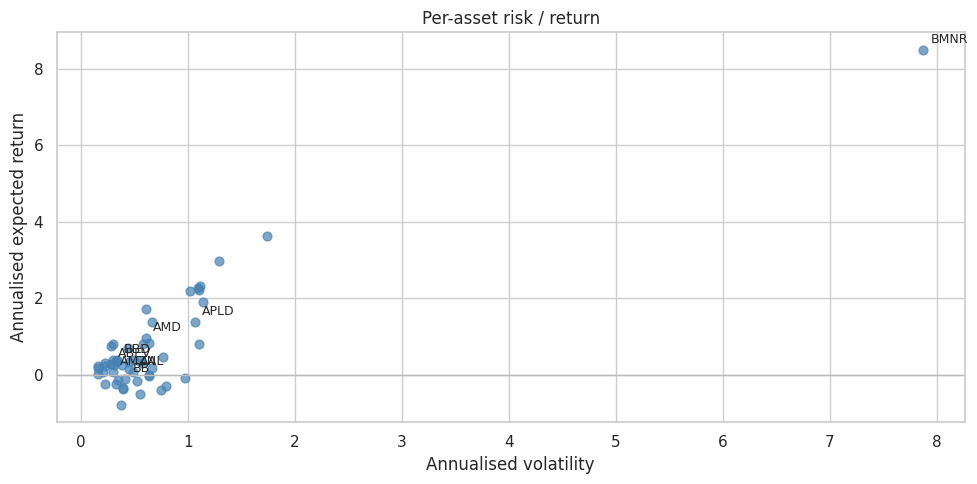

In [3]:
fig, ax = plt.subplots()
ax.scatter(
    summary["annual_volatility"],
    summary["annual_return"],
    s=40, alpha=0.7, color="steelblue",
)
for ticker, row in summary.head(8).iterrows():
    ax.annotate(ticker, (row["annual_volatility"], row["annual_return"]),
                xytext=(5, 5), textcoords="offset points", fontsize=9)
ax.set_xlabel("Annualised volatility")
ax.set_ylabel("Annualised expected return")
ax.set_title("Per-asset risk / return")
ax.axhline(0, color="#bbb", linewidth=1)
fig.tight_layout()
plt.show()

## 3. Two-asset warm-up

Before solving the full optimisation, we look at how a simple stocks/bonds split behaves. Variance for a two-asset portfolio is

$$\sigma_p^2 = w_1^2 \sigma_1^2 + w_2^2 \sigma_2^2 + 2 w_1 w_2 \rho_{12} \sigma_1 \sigma_2.$$

Sweeping $w_1$ from 0 to 1 traces a curve in (volatility, expected return) space.

[                       0%                       ]

[**********************50%                       ]  2 of 4 completed

[*********************100%***********************]  4 of 4 completed

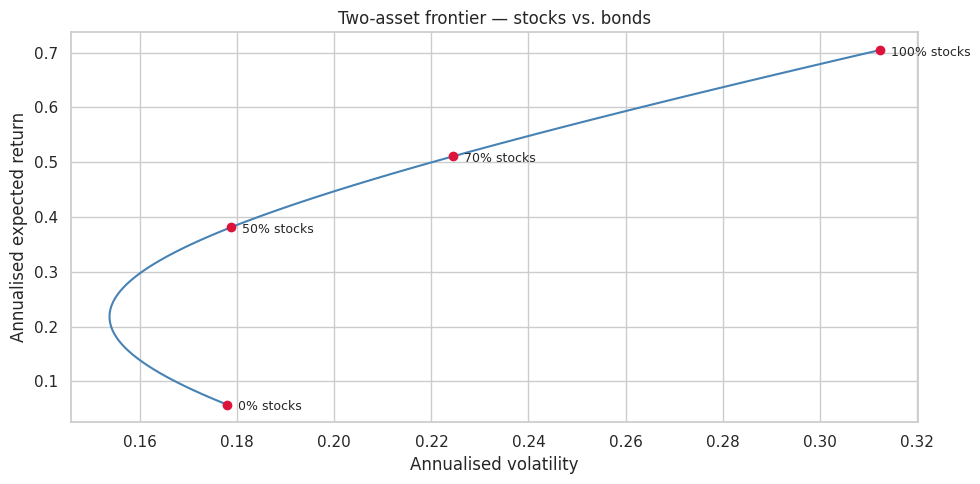

In [4]:
bond_prices = ingestion.get_bond_prices()
bond_returns = DataIngestion.compute_returns(bond_prices)

mu_stocks = stock_returns.mean().mean() * 252
mu_bonds = bond_returns.mean().mean() * 252
sd_stocks = stock_returns.mean(axis=1).std() * np.sqrt(252)
sd_bonds = bond_returns.mean(axis=1).std() * np.sqrt(252)
rho = stock_returns.mean(axis=1).corr(bond_returns.mean(axis=1))

weights = np.linspace(0, 1, 101)
expected_returns = weights * mu_stocks + (1 - weights) * mu_bonds
variances = (
    (weights ** 2) * sd_stocks ** 2
    + ((1 - weights) ** 2) * sd_bonds ** 2
    + 2 * weights * (1 - weights) * rho * sd_stocks * sd_bonds
)
volatilities = np.sqrt(variances)

fig, ax = plt.subplots()
ax.plot(volatilities, expected_returns, color="steelblue")
for w in [0.0, 0.5, 0.7, 1.0]:
    idx = int(w * 100)
    ax.scatter(volatilities[idx], expected_returns[idx], color="crimson", zorder=3)
    ax.annotate(
        f"{int(w * 100)}% stocks",
        (volatilities[idx], expected_returns[idx]),
        xytext=(8, -4), textcoords="offset points", fontsize=9,
    )
ax.set_xlabel("Annualised volatility")
ax.set_ylabel("Annualised expected return")
ax.set_title("Two-asset frontier — stocks vs. bonds")
fig.tight_layout()
plt.show()

## 4. Solving for the max-Sharpe portfolio

`portfolio_metrics` solves $\arg\max_w S(w)$ subject to $\sum_i w_i = 1$ and $w_i \ge 0$ (long-only, fully invested). The example below uses the stock universe with a 4 % annual risk-free rate.

In [5]:
# `pypfopt` requires at least one asset whose expected return
# exceeds the risk-free rate. We choose a small positive rate so
# the optimisation is feasible across most yfinance windows.
RISK_FREE_RATE = 0.01
metrics = portfolio_metrics(stock_prices, risk_free_rate=RISK_FREE_RATE)

print(f"Expected annual return: {metrics['expected_annual_return']:.4f}")
print(f"Annual volatility:      {metrics['annual_volatility']:.4f}")
print(f"Sharpe ratio:           {metrics['sharpe_ratio']:.4f}")

Expected annual return: 1.9444
Annual volatility:      0.1883
Sharpe ratio:           10.2703


### Visualising the optimal weights

Long-only max-Sharpe portfolios typically concentrate on a handful of historical winners. This is a known weakness of plug-in MPT: the historical mean is a noisy estimator of the future expected return. Production implementations apply shrinkage (Ledoit–Wolf), Black–Litterman views, or explicit weight caps to mitigate this.

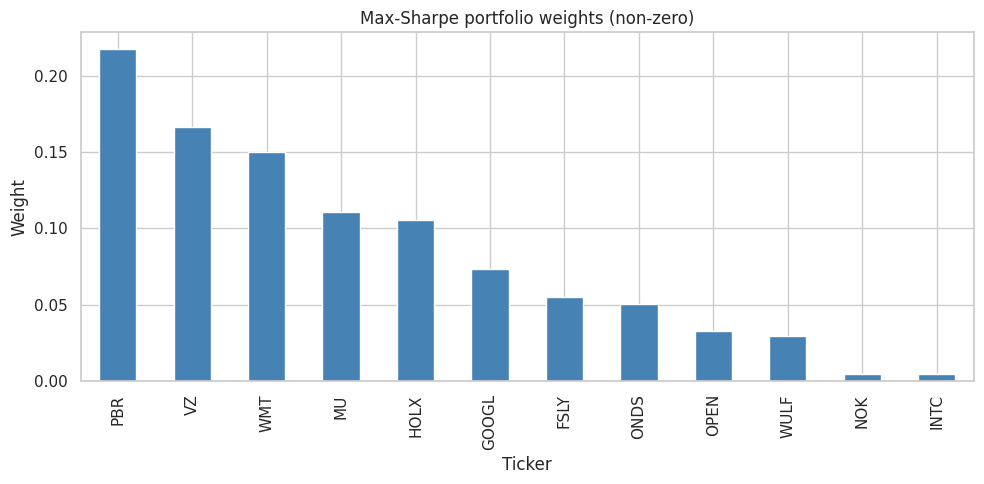

PBR      0.21759
VZ       0.16612
WMT      0.15038
MU       0.11089
HOLX     0.10526
GOOGL    0.07357
FSLY     0.05484
ONDS     0.05013
OPEN     0.03257
WULF     0.02978
NOK      0.00457
INTC     0.00429
dtype: float64

In [6]:
weights = pd.Series(metrics["weights"]).sort_values(ascending=False)
non_zero = weights[weights > 0]

fig, ax = plt.subplots(figsize=(10, 5))
non_zero.plot.bar(ax=ax, color="steelblue")
ax.set_title("Max-Sharpe portfolio weights (non-zero)")
ax.set_ylabel("Weight")
ax.set_xlabel("Ticker")
fig.tight_layout()
plt.show()

non_zero